Read warptemplates for some class and look at properties of the sample:
- Do we end up having a sufficient number of (good) sn / template combos? (or is the set too narrow)?
- Look at the peak colors of all models and fit some distribution.
- Find coefficients to standardize etc. 

In [1]:
import os, re, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import exponnorm
from pathlib import Path
from datetime import datetime
import pickle
import sncosmo

In [2]:
sys.path.append('/Users/jnordin/github/ampelFeb25')

In [3]:
from warpTemplate import WarpfitTemplateLoader, add_warpclasses

### Inspect the base warp template
How many combos?

In [4]:
# Which warp class to parse for?
# Category: (n)arrow, (e)xtended, (w)ide or (a)ll?
category = 'a'
# Id for class to run for
cid = 1

In [5]:
# Vetoed combos (peak color totally off)
toskip = []
toskip.append( 'ZTF21aanefkx_snana-2007lb+host' )      # Extreme color - must have gone wrong <

In [6]:
n_classlist = [
    'SN IIP', 'SN Ia-91T', 'SN IIn', 'SN Ib/c', 'SN Ibn', 'SN Ia-pec', 'SLSN-I', 
    'SN Ic', 'SN Ic-BL', 'SN II', 'SLSN-II', 'SN Iax', 'SN Ia-91bg', 'SN Ia-CSM', 
    'SN Ia-SC', 'SN Ib', 'SN IIb',
]
e_classlist = [
    'SN Ib/c (e)', 'SLSN (e)'
]
w_classlist = [
    'SLSN (w)', 'SN II (w)', 'SN Ib/c (w)',
    'SN Ia (w)', 'SN Ia-pec (w)',
]
a_classlist = [
    'SN Ia (a)', 'SN CC (a)'
]

In [7]:
# Load BTS information - mainly used to collect correct BTS name classes 
df_bts = pd.read_csv('/Users/jnordin/data/ztf/bts/bts_explorer_241122.csv')
df_bts = add_warpclasses(df_bts, purge=True)
classlist = list(set(df_bts['type_'+category]))
#class_name = n_classlist[cid]
#class_name = e_classlist[cid]
#class_name = w_classlist[cid]
class_name = a_classlist[cid]
#print('Target class {} from category {}'.format(class_name, 'type_'+category))
#classlist

In [8]:
# Parameters for fit template retrieval
exclude_input = [] # Will reject any warptemplate containing any of these (either as sn or template basis)
# How to define templates?
# - How many templates per sn basis? 
#      * if 'all' it will return one copy of each template, 
#.     * if int it will return that many, drawn according to the template probability, 
#      * if -int it will return that many copies drawn from a uniform probabilitiy
#      Note: draws made with replacement, so multiple copies can be returned if int is larger than the available number of templates (often 3)
template_selection = 'all'    # Use the same number per SN to keep balance 
# - How many sn basis?
#.     * if 'all', take one of each
#.     * if an int, draw these randomly (with replacement)
#.     Note: how many templates are returned is decided by the above parameter.
snbasis_selection = 'all'
# Which fit quality to require?
min_fit_quality = None

warpdir = '/Users/jnordin/data/models/sncosmo/warpmod'

In [9]:
warploader = WarpfitTemplateLoader(warpdir)

In [10]:
tcounting = {}
for quality in ['gold', 'silver', 'bronze']:
    print('running quality', quality)
    templates = warploader.get_templates(
        fitclass=class_name,
        exclude_input = exclude_input, 
        template_selection=template_selection,
        snbasis_selection=snbasis_selection,
        min_fit_quality=quality,
        random_seed=42
    )
    # Analyse the results
    tmodels = [
        template['model'].description for template in templates
    ]
    tcounting[quality+'_nbr_models'] =  len(tmodels)
    tcounting[quality+'_nbr_sne'] =  len( set([ tmodel.split('_')[0] for tmodel in tmodels]) )
    tcounting[quality+'_nbr_templates']:  len( set([ tmodel.split('_')[1] for tmodel in tmodels]) )

2026-06-19 06:45:54,395 [INFO] Using random seed: 42
2026-06-19 06:45:54,395 [INFO] Loading warpcoeffs from /Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_v2_SN CC (a).pkl
2026-06-19 06:45:54,404 [INFO] Filtering SN bases with min_fit_quality=gold
2026-06-19 06:45:54,405 [INFO] SN basis ZTF18aanjzkp: 5 templates after quality filtering (5 original)
2026-06-19 06:45:54,405 [INFO] SN basis ZTF18abffyqp: 2 templates after quality filtering (3 original)
2026-06-19 06:45:54,405 [INFO] SN basis ZTF18abfzhct: 5 templates after quality filtering (7 original)
2026-06-19 06:45:54,405 [INFO] SN basis ZTF18abiiqdl: 0 templates after quality filtering (1 original)
2026-06-19 06:45:54,406 [INFO] SN basis ZTF18abltfho: 4 templates after quality filtering (5 original)
2026-06-19 06:45:54,406 [INFO] SN basis ZTF18abrlljc: 5 templates after quality filtering (5 original)
2026-06-19 06:45:54,406 [INFO] SN basis ZTF18abyvenk: 4 templates after quality filtering (12 original)
2026-06-19 06:45:54,406

running quality gold


2026-06-19 06:46:06,729 [INFO] Returning 1398 templates
2026-06-19 06:46:06,730 [INFO] Using random seed: 42
2026-06-19 06:46:06,730 [INFO] Filtering SN bases with min_fit_quality=silver
2026-06-19 06:46:06,730 [INFO] SN basis ZTF18aanjzkp: 5 templates after quality filtering (5 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abffyqp: 2 templates after quality filtering (3 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abfzhct: 5 templates after quality filtering (7 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abiiqdl: 0 templates after quality filtering (1 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abltfho: 4 templates after quality filtering (5 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abrlljc: 5 templates after quality filtering (5 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18abyvenk: 4 templates after quality filtering (12 original)
2026-06-19 06:46:06,731 [INFO] SN basis ZTF18acbwasc: 0 templates after quality filtering (

running quality silver


2026-06-19 06:46:12,685 [INFO] Returning 1398 templates
2026-06-19 06:46:12,743 [INFO] Using random seed: 42
2026-06-19 06:46:12,743 [INFO] Filtering SN bases with min_fit_quality=bronze
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18aanjzkp: 5 templates after quality filtering (5 original)
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18abffyqp: 3 templates after quality filtering (3 original)
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18abfzhct: 7 templates after quality filtering (7 original)
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18abiiqdl: 1 templates after quality filtering (1 original)
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18abltfho: 5 templates after quality filtering (5 original)
2026-06-19 06:46:12,744 [INFO] SN basis ZTF18abrlljc: 5 templates after quality filtering (5 original)
2026-06-19 06:46:12,745 [INFO] SN basis ZTF18abyvenk: 12 templates after quality filtering (12 original)
2026-06-19 06:46:12,745 [INFO] SN basis ZTF18acbwasc: 1 templates after quality filtering 

running quality bronze


2026-06-19 06:46:20,378 [INFO] Returning 1702 templates


In [11]:
tcounting

{'gold_nbr_models': 1398,
 'gold_nbr_sne': 328,
 'silver_nbr_models': 1398,
 'silver_nbr_sne': 328,
 'bronze_nbr_models': 1702,
 'bronze_nbr_sne': 349}

In [12]:
# Generate templates for studies

In [13]:
templates = warploader.get_templates(
    fitclass=class_name,
    exclude_input = exclude_input, 
    template_selection=template_selection,
    snbasis_selection=snbasis_selection,
    min_fit_quality=min_fit_quality,
    random_seed=42
)

2026-06-19 06:46:20,459 [INFO] Using random seed: 42
2026-06-19 06:46:20,459 [INFO] 349 SN bases available after filtering
2026-06-19 06:46:27,824 [INFO] Returning 1702 templates


In [14]:
class_name

'SN CC (a)'

In [15]:
# Which colors do we use for peak estimate
colband = ['bessellb','bessellv']
# For some templates this does not seem to work?
if class_name in [ 
    'SN Ia-91T', 'SN Ia-pec', 'SLSN-I', 'SLSN-II', 'SN Ia-SC', 'SLSN (e)', 
    'SLSN (w)', 'SN Ia (w)', 'SN Ia-pec (w)', 'SN Ia (a)', 'SN CC (a)']:
    colband = ['ztfr','ztfi']
#if template_class_id in [3,9]:
#    # SLSN - templates start redder, using different bands
#    # but why also 91t?
#    colband = ['ztfr','ztfi']
#else:
#    colband = ['ztfg','ztfr']
#colband = ['bessellb','bessellv']

In [16]:
cols = {}
peakphases = {}
for t in templates:
    # So - the current method in peakfitting_gp first fits the peak in each individual band
    # and then gets the color from the respective peaks. So do the same for the templates

    if t['model'].description in toskip:
        print('skipping ...', t['model'].description)
        continue
    
    # What is the peak phase
    t0_0 = t['model'].source.peakphase(colband[0])
    t0_1 = t['model'].source.peakphase(colband[1])
    peakphases[t['model'].description] = {
        colband[0]:t0_0,
        colband[1]:t0_1,        
    }

    cols[t['model'].description] = t['model'].bandmag(colband[0], 'ab', t0_0)-t['model'].bandmag(colband[1], 'ab', t0_1)
    

skipping ... ZTF21aanefkx_snana-2007lb+host


(array([  1.,   0.,   2.,   2.,   4.,  74., 926., 596.,  85.,  11.]),
 array([-2.84418586, -2.43510869, -2.02603152, -1.61695434, -1.20787717,
        -0.7988    , -0.38972283,  0.01935435,  0.42843152,  0.83750869,
         1.24658587]),
 <BarContainer object of 10 artists>)

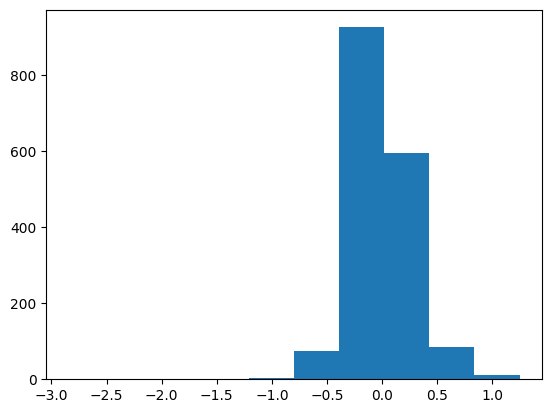

In [17]:
plt.hist( cols.values(),bins=10 )
#plt.xlim([-1,2])

So it looks like these can be faaairly well behaved, described as some gaussian and then a tail to redder. So could fit one of these for each subclass? Then (i) fit a gaussian + exponential for each class (ii) record for each template the g-r color and the difference compared with the gaussian peak. This will be the initial Ebv diff. (iii) When simulating, draw a value from the combined guass + exp as the observed peak color (iv) set the template host color to this value and use for simulations.

#### Filtering
Differnt options for removing outliers prior to fitting the distribution

In [18]:
def iqr_filter(data, k=1.5):
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return data[(data >= lower) & (data <= upper)]
def central_mask(data, lower_pct=5, upper_pct=95):
    lo, hi = np.percentile(data, [lower_pct, upper_pct])
    return data[(data >= lo) & (data <= hi)]

In [19]:
cols.values()

dict_values([-0.3016102190876744, 0.20307212894666193, 0.14536322418937786, 0.6056206204238812, 0.20033936799616114, 0.12467247872916687, -0.9258879181965014, -0.37399798306118015, -0.10912697127028181, 0.14120258922304885, -0.3109956242163143, -0.2910970712045824, 0.004993531292296183, 0.12453581917508671, 0.07824265209637105, 0.22147285411526596, 0.10347058861151837, 0.6513822839331169, 0.5993750373612023, 0.41125474700328724, 0.2838824853446589, -0.05488954608035357, -0.03572220507951229, 0.02699806121817261, -0.07981251956020685, 0.7388464855259791, -0.3404607965754316, 0.2153985778289318, -0.4539177306782243, -0.3156738504068226, -0.18579881007189059, -0.05029020382025351, -0.43001215992825337, -0.018854991264657173, -0.3137257726792484, 0.1406385020443679, -0.03975634176325116, -0.13346219626616573, -0.34582575545002214, 0.20612777879951238, -0.1325259875241116, -0.11692501249986265, -0.13974587368059233, 0.0042419403932640876, 0.09585870853029732, -0.19463564317410587, -0.218504

In [20]:
q1, q3 = np.percentile(list(cols.values()), [25, 75])

In [21]:
d1 = np.array(list(cols.values()))[np.array(list(cols.values()))>-np.inf]

In [22]:
len(d1)

1701

In [23]:
# Below follows a recommendation for asymmetric rejection, probably cannot claim ..
# Step 1: remove extreme garbage only
d2 = iqr_filter(d1, k=3)

In [24]:
len(d2)

1689

In [25]:
core = central_mask(d2, 5, 95)

In [26]:
len(core)

1519

In [27]:
mu, sigma = np.mean(core), np.std(core)

In [28]:
print(mu, sigma)

-0.008499545181986432 0.17220618338473706


In [29]:
# Step 3: asymmetric clipping
d3 = d2[(d2 > mu - 5*sigma) & (d2 < mu + 5*sigma)]

In [30]:
len(d3)

1685

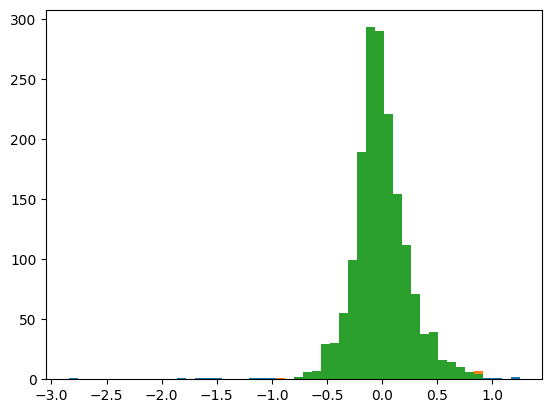

In [31]:
_, bins, __ = plt.hist(d1,bins=50)
_ = plt.hist(d2,bins=bins)
_ = plt.hist(d3,bins=bins)

In [32]:
# What are we running with? depend on the sample size to some extent
if len(cols.values())<5:
    mydata = d1      # Only rempve Nan
else:
    #mydata = d2     # Mild filtering
    mydata = d3     # Five sigma rejection

# Do we need filtering? so far not ....
mydata = d1
#if class_name in ['SLSN-II']:    # One large outlier
#    mydata = d2

In [33]:

def fit_emg_and_store(data, model_name, col1, col2, outfile="warptemplate_v2_color_fits.csv", also_store={}):
    # Fit
    K, loc, scale = exponnorm.fit(data)

    # Create row
    result = {
        "model": model_name,
        "K": K,
        "loc": loc,
        "scale": scale,
        "color1": col1,
        "color2": col2,
        "n": len(data)
    }
    result.update( also_store )
    result["timestamp"] = datetime.utcnow().isoformat()

    # Convert to DataFrame
    df = pd.DataFrame([result])

    # Append to file
    file = Path(outfile)
    if file.exists():
        df.to_csv(file, mode="a", header=False, index=False)
    else:
        df.to_csv(file, index=False)

    return K, loc, scale

In [34]:
K, loc, scale = fit_emg_and_store(mydata, class_name, colband[0], colband[1], also_store=tcounting )

In [35]:
print(K, loc, scale)

0.44453155868593175 -0.1173046250802458 0.2473843899594283


In [36]:
# Construct how many bins
if len(mydata)<30:
    bins = 5
elif len(mydata)<120:
    bins = 10
else:
    bins = 20

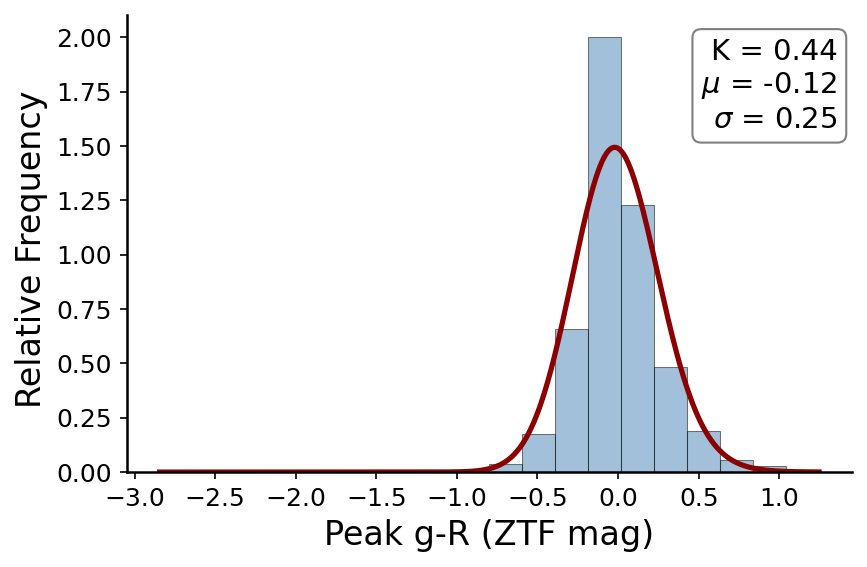

In [37]:

# Plot ranges
s, e = min(mydata), max(mydata)

s = min(s, loc-0.8)
e = max(e, loc+1.2)


# -------------------
# Smooth PDF
# -------------------
x = np.linspace(s, e, 1000)
pdf = exponnorm.pdf(x, K, loc=loc, scale=scale)

# -------------------
# Style (publication-ready)
# -------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "figure.dpi": 150,
})

fig, ax = plt.subplots(figsize=(6, 4))

# Histogram
ax.hist(mydata, bins=bins, density=True,
        alpha=0.5, color="steelblue",
        edgecolor="black", linewidth=0.5,
        label="Data")

# Fit curve
ax.plot(x, pdf, color="darkred", lw=2.5,
        label="EMG fit")

# Labels
ax.set_xlabel("Peak g-R (ZTF mag)")
ax.set_ylabel("Relative Frequency ")

# Legend
#ax.legend(frameon=False)

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

text = (
    f"K = {K:.2f}\n"
    f"$\\mu$ = {loc:.2f}\n"
    f"$\\sigma$ = {scale:.2f}"
)

ax.text(0.98, 0.95, text,
        transform=ax.transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round", fc="white", ec="gray"))


# Tight layout
plt.tight_layout()

plt.savefig("/Users/jnordin/tmp/warpfigs/emg_fit_{}.png".format(class_name.replace("/","")), bbox_inches="tight",dpi=300)

plt.show()

### Individual color correction
As done in warpcoeff_distcolcorr

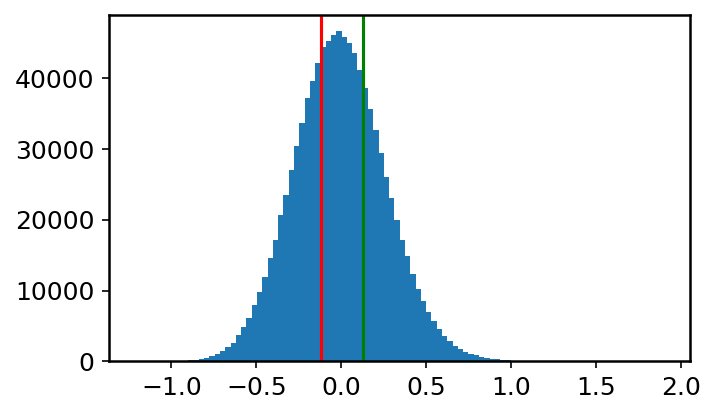

In [38]:
# Inspect prediction
from scipy.stats import exponnorm
emg_dist = exponnorm(K, loc, scale)
dsim = emg_dist.rvs(size=1000000, random_state=41)
plt.figure(figsize=(5,3))
_ = plt.hist(dsim,bins=100)
plt.axvline(x=loc,color='red')
plt.axvline(x=loc+scale,color='green')

In [39]:
# Now we wish to loop through all sncosmo templates and:
# - measure the template peak phase color
# - calculate which extinction would need to be applied to this template to achieve the class color 
# - create a modified version of the template warp coefficients that lead to the desired color
# - store the new version 

In [40]:
    def color_with_ebv(warped_model, ebv, rv, band1, band2, t0_1, t0_2):
        warped_model.set(hostebv=ebv, hostr_v=rv)
        return (
            warped_model.bandmag(band1, 'ab', t0_1)
            - warped_model.bandmag(band2, 'ab', t0_2)
        )

In [41]:
import sncosmo
from scipy.optimize import brentq
from scipy.optimize import minimize_scalar

In [42]:
ebvout = {}
colfits = []
for k, t in enumerate(templates):

    # This 
    mod = t['model']
    modid = mod.description
    source = mod.source

    if modid in toskip:
        print('... skipping', modid)
        continue


    # Help functions
    warped_model = sncosmo.Model(
        source=source,
        effects=[sncosmo.CCM89Dust()],
        effect_names=['host'],
        effect_frames=['rest']
    )
    # How to do with readshift? Are we talking about observed peak color, or restframe peak color?
#    warped_model.set(z=mod.get('z'))
    warped_model.set(z=0)

    # We first determine the native peak col
#    natcol = color_with_ebv(warped_model, 0, 3.1, 
#                            colband[0], colband[1], 
#                            peakphases[modid][colband[0]], peakphases[modid][colband[1]],
#                           )
    natcol = cols[modid]
    print(k, modid, natcol)

    def fit_function( ebv ):
        return np.abs( color_with_ebv( 
                            warped_model, ebv, 3.1, 
                            colband[0], colband[1], 
                            peakphases[modid][colband[0]], peakphases[modid][colband[1]],
                        )-target_col
                     )
    
    # We now generate and loop through a number of simulated peak colors 
    for target_col in list(emg_dist.rvs(size=100)):
        # Determine which ebv is needed 
        # Look for the dust color ebv minimizing the difference
        try:
#            ebv_solution = brentq(fit_function, -5.0, 5.0, maxiter=100, )
            ebv_solution = minimize_scalar(fit_function)#, bounds=(-5.0, 5.0), method='bounded')

            if ebv_solution.success:

                res = color_with_ebv( 
                            warped_model, ebv_solution.x, 3.1, 
                            colband[0], colband[1], 
                            peakphases[modid][colband[0]], peakphases[modid][colband[1]],
                        )
#                print('got fit: target {:.2} from native col {:.2} fitted ebv {:.2} yield color {:.2} with diff {:.2f}'.format(
#                    target_col, natcol, ebv_solution.x, res, res-target_col )
#                     )

                
                # Store for analysis
                colfits.append(
                    {
                        'k': k,
                        'sn': modid,
                        'z': mod.get('z'),
                        'natcol': natcol,
                        'targetcol': target_col,
                        'ebvfit': ebv_solution.x
                    }
                )
            else:
                print('fit not success', target_col, natcol, natcol-target_col)
                    
        except KeyError:
            # fallback if root not bracketed
            print('fit fail', target_col, natcol, natcol-target_col)
            ebv_solution = -99
#    break

0 ZTF18aanjzkp_v19-2007uy-corr+host -0.3016102190876744
1 ZTF18aanjzkp_v19-2008aq-corr+host 0.20307212894666193
2 ZTF18aanjzkp_v19-2008bo-corr+host 0.14536322418937786
3 ZTF18aanjzkp_v19-2011dh-corr+host 0.6056206204238812
4 ZTF18aanjzkp_v19-2011hs-corr+host 0.20033936799616114
5 ZTF18abffyqp_snana-2006kv+host 0.12467247872916687
6 ZTF18abffyqp_snana-2006kn+host -0.9258879181965014
7 ZTF18abffyqp_v19-2004aw-corr+host -0.37399798306118015
8 ZTF18abfzhct_v19-2006ep-corr+host -0.10912697127028181
9 ZTF18abfzhct_snana-2006ep+host 0.14120258922304885
10 ZTF18abfzhct_v19-iptf13bvn-corr+host -0.3109956242163143
11 ZTF18abfzhct_v19-2007gr-corr+host -0.2910970712045824
12 ZTF18abfzhct_v19-2005bf-corr+host 0.004993531292296183
13 ZTF18abfzhct_v19-2004gq-corr+host 0.12453581917508671
14 ZTF18abfzhct_v19-1999dn-corr+host 0.07824265209637105
15 ZTF18abiiqdl_snana-2007lb+host 0.22147285411526596
16 ZTF18abltfho_snana-2006ix+host 0.10347058861151837
17 ZTF18abltfho_snana-2007nv+host 0.651382283933116

/opt/homebrew/Caskroom/miniconda/base/envs/ampelFeb25/lib/python3.10/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


fit not success -0.5613116008722563 0.4020205615035728 0.9633321623758291
fit not success -0.4771532446507437 0.4020205615035728 0.8791738061543165
914 ZTF20achvdtx_v19-2011bm-corr+host 0.09807997504426602
915 ZTF20achvdtx_snana-2006kn+host 0.07076908316833652
916 ZTF20achvdtx_v19-1987a-corr+host 0.07140134928321373
917 ZTF20achvdtx_snana-2005hm+host 0.10771030915146085
918 ZTF20achvdtx_v19-2009kr-corr+host 0.14607219320361864
919 ZTF20achvdtx_snana-2007ms+host -0.039965514990086604
920 ZTF20achvdtx_snana-2004hx+host -0.14903716386590204
921 ZTF20acitoie_v19-2008bj-corr+host -0.1510115141452033
922 ZTF20acitoie_v19-2006aa-corr+host 0.2659387688115089
923 ZTF20aciubfx_v19-2004aw-corr+host -0.049382863574191305
924 ZTF20aciubfx_v19-2009jf-corr+host -0.02525410783839277
925 ZTF20aciubfx_v19-2004gt-corr+host -0.020316329255049226
926 ZTF20aciubfx_v19-2012au-corr+host -0.029823050720867883
927 ZTF20aciubfx_v19-2005hg-corr+host -0.2710859111042865
928 ZTF20aciubfx_v19-1999dn-corr+host -0.063

In [43]:
dfcol = pd.DataFrame.from_dict( colfits )

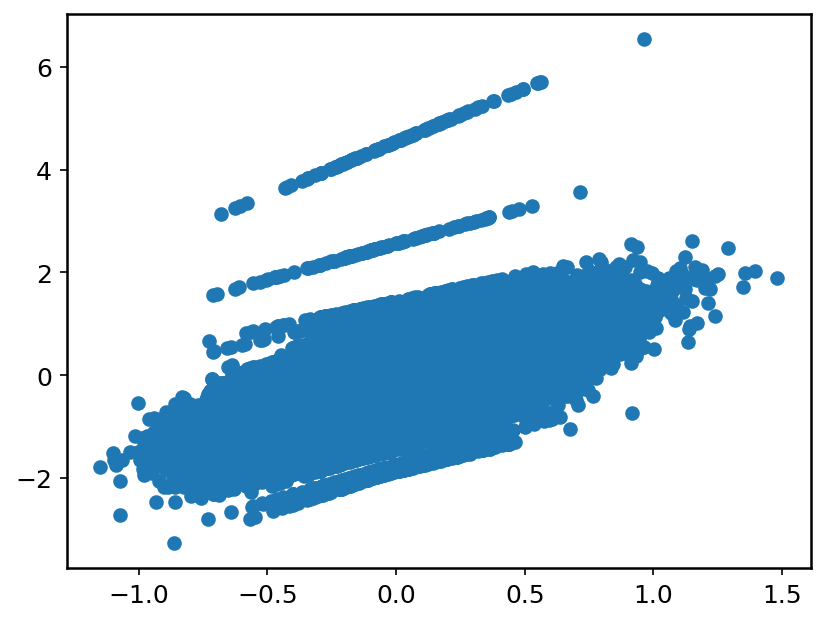

In [44]:
plt.scatter( dfcol['targetcol'], dfcol['ebvfit'] )

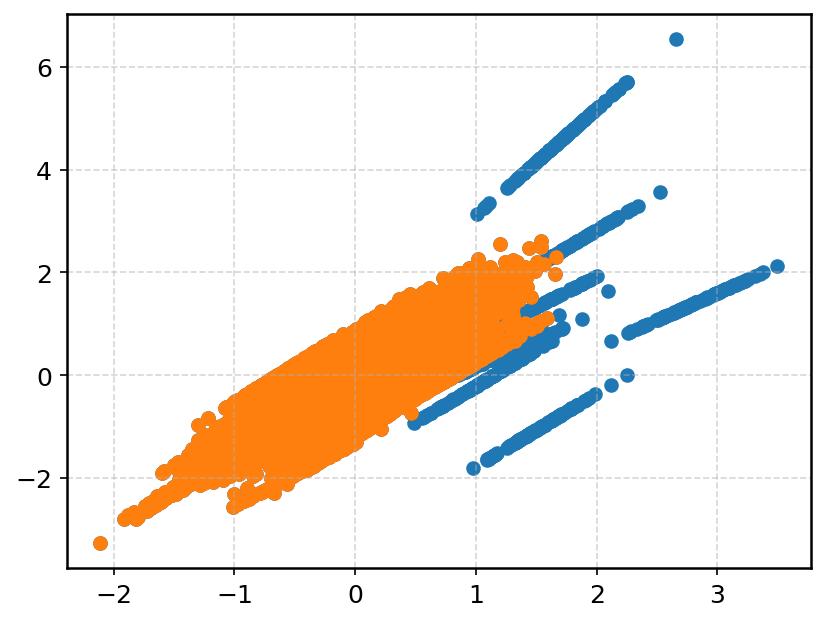

In [45]:
plt.scatter( dfcol['targetcol']-dfcol['natcol'], dfcol['ebvfit'] )
mask = (dfcol['natcol']>-1)
plt.scatter( dfcol['targetcol'][mask]-dfcol['natcol'][mask], dfcol['ebvfit'][mask] )
plt.grid(linestyle="--",alpha=0.5,zorder=1)

In [46]:
import numpy as np
import matplotlib.pyplot as plt

x = dfcol['targetcol'] - dfcol['natcol']
y = dfcol['ebvfit']
z = dfcol['natcol']

# Fit quadratic
if class_name in ['SLSN-I','SLSN-II','SLSN (e)','SLSN (w)']:
    # Some peak lc fits fail
    mask = (dfcol['natcol']>-1)
    coeffs = np.polyfit(x[mask], y[mask], 3)
elif class_name in ['SN Ic-BL']:
    # Some peak lc fits fail
    mask = (dfcol['natcol']<1)
    coeffs = np.polyfit(x[mask], y[mask], 3)
else:
    coeffs = np.polyfit(x, y, 3)
    
poly = np.poly1d(coeffs)

# Generate smooth curve
x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = poly(x_fit)

In [47]:
class_name

'SN CC (a)'

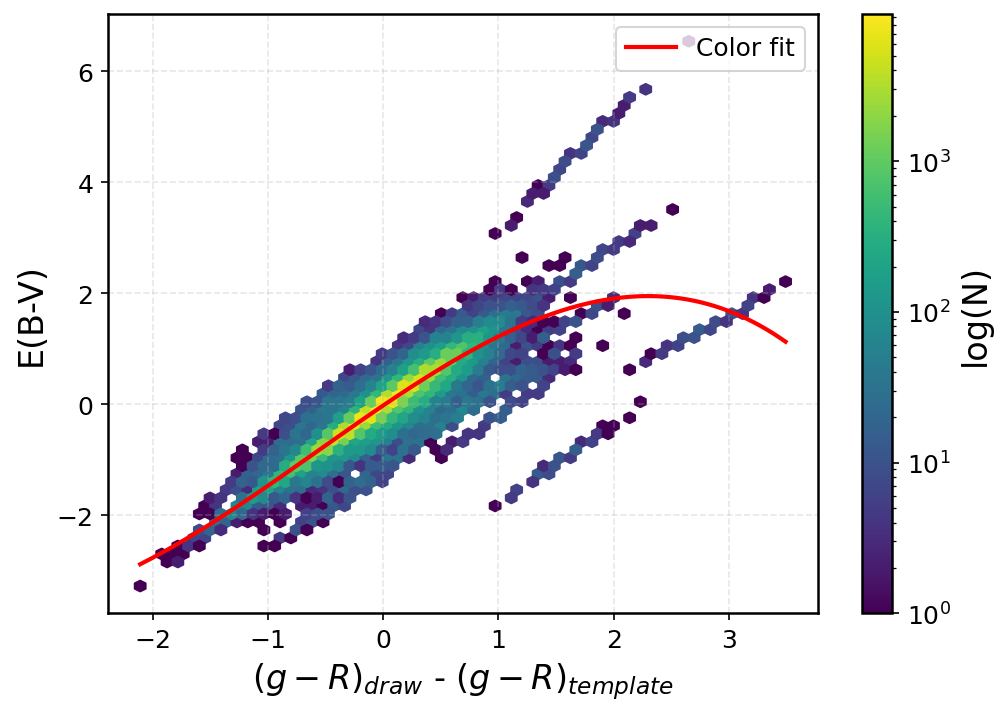

In [48]:
plt.figure(figsize=(7,5))

hb = plt.hexbin(x, y, gridsize=60, cmap='viridis', bins='log')
plt.colorbar(hb, label='log(N)')

plt.plot(x_fit, y_fit, color='red', linewidth=2, label='Color fit')

plt.grid(linestyle="--", alpha=0.3)
plt.legend()

plt.xlabel(r"$(g-R)_{draw}$ - $(g-R)_{template}$")
plt.ylabel("E(B-V)")
plt.tight_layout()
plt.savefig('distcolcorr_{}.pdf'.format(class_name.replace("/","")),dpi=300)
plt.show()

### Construct color information warpfiles

                "model_colors": dict    # Fit parameters of the original template fit (e.g. for color harmonization)
                    {
                        'K': 0.9079106174117336,
                        'loc': 0.1250977286061127,
                        'scale': 0.1514897618587996,
                        'color1': 'ztfg',
                        'color2': 'ztfr',
                        'ebv_corr_func': [-0.0001, 0.01, 0.5]  # polynomial coefficients to map from drawn color to E(B-V) correction
                    },



In [49]:
model_colors = {
    'K': K, 
    'loc': loc, 
    'scale': scale, 
    'color1': colband[0],
    'color2': colband[1],
    'ebv_corr_func': list(coeffs)
}

In [50]:
model_colors

{'K': 0.44453155868593175,
 'loc': -0.1173046250802458,
 'scale': 0.2473843899594283,
 'color1': 'ztfr',
 'color2': 'ztfi',
 'ebv_corr_func': [-0.058833086689744865,
  -0.10210423309691559,
  1.4025823995163806,
  -0.0197958414807449]}

In [51]:
# Ok, so this information will be the same for each class - maybe store somwhere in code?
# What we would want in the warpfiles is the calculated peak color

In [52]:
data = warploader._cache[class_name.replace("/","")]

In [53]:
len(data)

349

In [54]:
toskip

['ZTF21aanefkx_snana-2007lb+host']

In [55]:
newdata = {}
for snbase, snwarplist in data.items():
    newdata[snbase] = []
    for snwarp in snwarplist:
        mname = snwarp['id']+'_'+snwarp['model']
        if mname+'+host' in toskip:
            print('skip comb:', mname)
            continue
        snwarp['peakcol'] = cols[mname+'+host']
        print(mname, natcol)
        newdata[snbase].append( snwarp )

ZTF18aanjzkp_v19-2007uy-corr -0.3034810497410625
ZTF18aanjzkp_v19-2008aq-corr -0.3034810497410625
ZTF18aanjzkp_v19-2008bo-corr -0.3034810497410625
ZTF18aanjzkp_v19-2011dh-corr -0.3034810497410625
ZTF18aanjzkp_v19-2011hs-corr -0.3034810497410625
ZTF18abffyqp_snana-2006kv -0.3034810497410625
ZTF18abffyqp_snana-2006kn -0.3034810497410625
ZTF18abffyqp_v19-2004aw-corr -0.3034810497410625
ZTF18abfzhct_v19-2006ep-corr -0.3034810497410625
ZTF18abfzhct_snana-2006ep -0.3034810497410625
ZTF18abfzhct_v19-iptf13bvn-corr -0.3034810497410625
ZTF18abfzhct_v19-2007gr-corr -0.3034810497410625
ZTF18abfzhct_v19-2005bf-corr -0.3034810497410625
ZTF18abfzhct_v19-2004gq-corr -0.3034810497410625
ZTF18abfzhct_v19-1999dn-corr -0.3034810497410625
ZTF18abiiqdl_snana-2007lb -0.3034810497410625
ZTF18abltfho_snana-2006ix -0.3034810497410625
ZTF18abltfho_snana-2007nv -0.3034810497410625
ZTF18abltfho_snana-2007md -0.3034810497410625
ZTF18abltfho_snana-2007lx -0.3034810497410625
ZTF18abltfho_snana-2007ms -0.303481049741

In [56]:
warpdata = {
    'warpcoeff': newdata,
    'model_colors': model_colors,
}

In [57]:
storefile = '/Users/jnordin/data/models/sncosmo/warpmod/warpcoeffs_v3_'+re.sub(r'/', '', class_name)+'.pkl'

In [58]:
with open(storefile, 'wb') as file:
    pickle.dump(warpdata, file)